In [1]:
import sys
import os
from pathlib import Path
root = Path().resolve().parent.parent
sys.path.append(str(root))  # Add the root of the |project to the local path

In [2]:
import numpy as np
import numpy.linalg as la
import pandas as pd
import matplotlib.pyplot as plt
import numpy.random as rand
import src.NSMap as ns
import src.NonstationarityTest as nt
import json

%load_ext autoreload
%autoreload 2

In [3]:
filename = "../../datasets/paramecium_didinium_cleaned.csv"

df = pd.read_csv(filename, encoding="utf-8", na_filter=False)
table = df.to_numpy()

In [4]:
# Load parameters from JSON file
def load_params(json_path):
    with open(json_path, 'r') as f:
        return json.load(f)

params = load_params("paramecium_didinium_params.json")

In [5]:
E_range = params["E_range"]
lambda1 = params["lambda1"]
lambda2 = params["lambda2"]
p = params["p"]
resolution = params["resolution"]
theta_range = params["theta_range"]
delta_range = params["delta_range"]
tau = params["tau"]

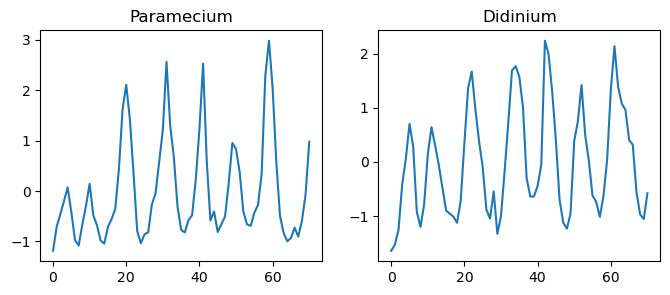

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))

paramecium = ns.standardize(table[:,0])
didinium = ns.standardize(table[:,1])

ax[0].plot(paramecium)
ax[0].set_title("Paramecium")

ax[1].plot(didinium)
ax[1].set_title("Didinium")

plt.show()

In [8]:
tx = np.linspace(0, 1, len(paramecium))
data_par = (paramecium, tx, tau)

evidence_par, significance_level_par, best_params_par = nt.nonstationarity_test(data_par, theta_range=theta_range, delta_range=delta_range, E_range=E_range, lambda1=lambda1, lambda2=lambda2, p=p, resolution=resolution, return_best_params=True)
# delta_agg_p, theta_agg_p, r_sqrd_p = ns.get_delta_agg(paramecium, 4, return_forecast_skill=True)

In [14]:
best_theta_ns, best_delta_ns, best_E_ns = best_params_par

# Compute prediction skill for best parameters
Xemb_ns, Y, tx = ns.delayEmbed(paramecium, best_E_ns, tau, t = np.linspace(0, 1, len(paramecium)))
Yhat_ns = ns.leaveOneOut(Xemb_ns, Y, tx, best_theta_ns, best_delta_ns)
ss_res_ns = np.sum((Y.flatten() - Yhat_ns.flatten())**2)
ss_tot_ns = np.sum((Y.flatten() - np.mean(Y))**2)
prediction_skill_ns = 1 - ss_res_ns / ss_tot_ns if ss_tot_ns > 0 else np.nan

print(f"Paramecium NSE = {prediction_skill_ns.item():.3f}")

Paramecium NSE = 0.792


In [15]:
tx = np.linspace(0, 1, len(didinium))
data_did = (didinium, tx, tau)

evidence_did, significance_level_did, best_params_did = nt.nonstationarity_test(data_did, theta_range=theta_range, delta_range=delta_range, E_range=E_range, lambda1=lambda1, lambda2=lambda2, p=p, resolution=resolution, return_best_params=True)
# delta_agg_d, theta_agg_d, r_sqrd_d = ns.get_delta_agg(didinium, 4, return_forecast_skill=True)

In [17]:
best_theta_ns, best_delta_ns, best_E_ns = best_params_did

# Compute prediction skill for best parameters
Xemb_ns, Y, tx = ns.delayEmbed(didinium, best_E_ns, tau, t = np.linspace(0, 1, len(didinium)))
Yhat_ns = ns.leaveOneOut(Xemb_ns, Y, tx, best_theta_ns, best_delta_ns)
ss_res_ns = np.sum((Y.flatten() - Yhat_ns.flatten())**2)
ss_tot_ns = np.sum((Y.flatten() - np.mean(Y))**2)
prediction_skill_ns = 1 - ss_res_ns / ss_tot_ns if ss_tot_ns > 0 else np.nan

print(f"Didinium NSE = {prediction_skill_ns.item():.3f}")

Didinium NSE = 0.737


In [ ]:
print("Paramecium")
print(f"p(NS) = {significance_level_par:0.3f}")

print("Didinium")
print(f"p(NS) = {significance_level_did:0.3f}")

Paramecium
p(NS) = 0.014
Didinium
p(NS) = 0.022


In [ ]:
"""
print("Paramecium")
print(f"aggregated delta = {delta_agg_p:0.3f}, r_sqrd = {r_sqrd_p:0.3f}")

print("Didinium")
print(f"aggregated delta = {delta_agg_d:0.3f}, r_sqrd = {r_sqrd_d:0.3f}")
"""

Paramecium
aggregated delta = 0.009, r_sqrd = 0.771
Didinium
aggregated delta = 0.083, r_sqrd = 0.737
